# Implement decision tree from Scratch

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pprint

### Loading Data

In [ ]:
df = pd.read_csv("../../../data/breast-cancer.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
df.drop('id', axis = 1, inplace = True)

In [4]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Exploratory Data Analysis (EDA)

In [5]:
px.pie(df, 'diagnosis', color='diagnosis', color_discrete_sequence=['#007500', '#5Cff5c'], title="Data Distribution")

We can tell the data is not balanced, thus accuracy wouldn't be a good evaluation metrix for this dataset.

In [6]:
for column in df.drop('diagnosis', axis = 1).columns[:5]:
    fig = px.box(data_frame=df, x='diagnosis', color="diagnosis", y=column, 
                 color_discrete_sequence=['#007500','#5CFF5C'], orientation='v')
    fig.show()

In [7]:
for column in  df.drop('diagnosis',axis=1).columns[5:10]:
    fig = px.scatter(data_frame=df,color='diagnosis',x=column,color_discrete_sequence=['#007500','#5CFF5C'],)
    fig.show()  

##### Checking Correlation with the target

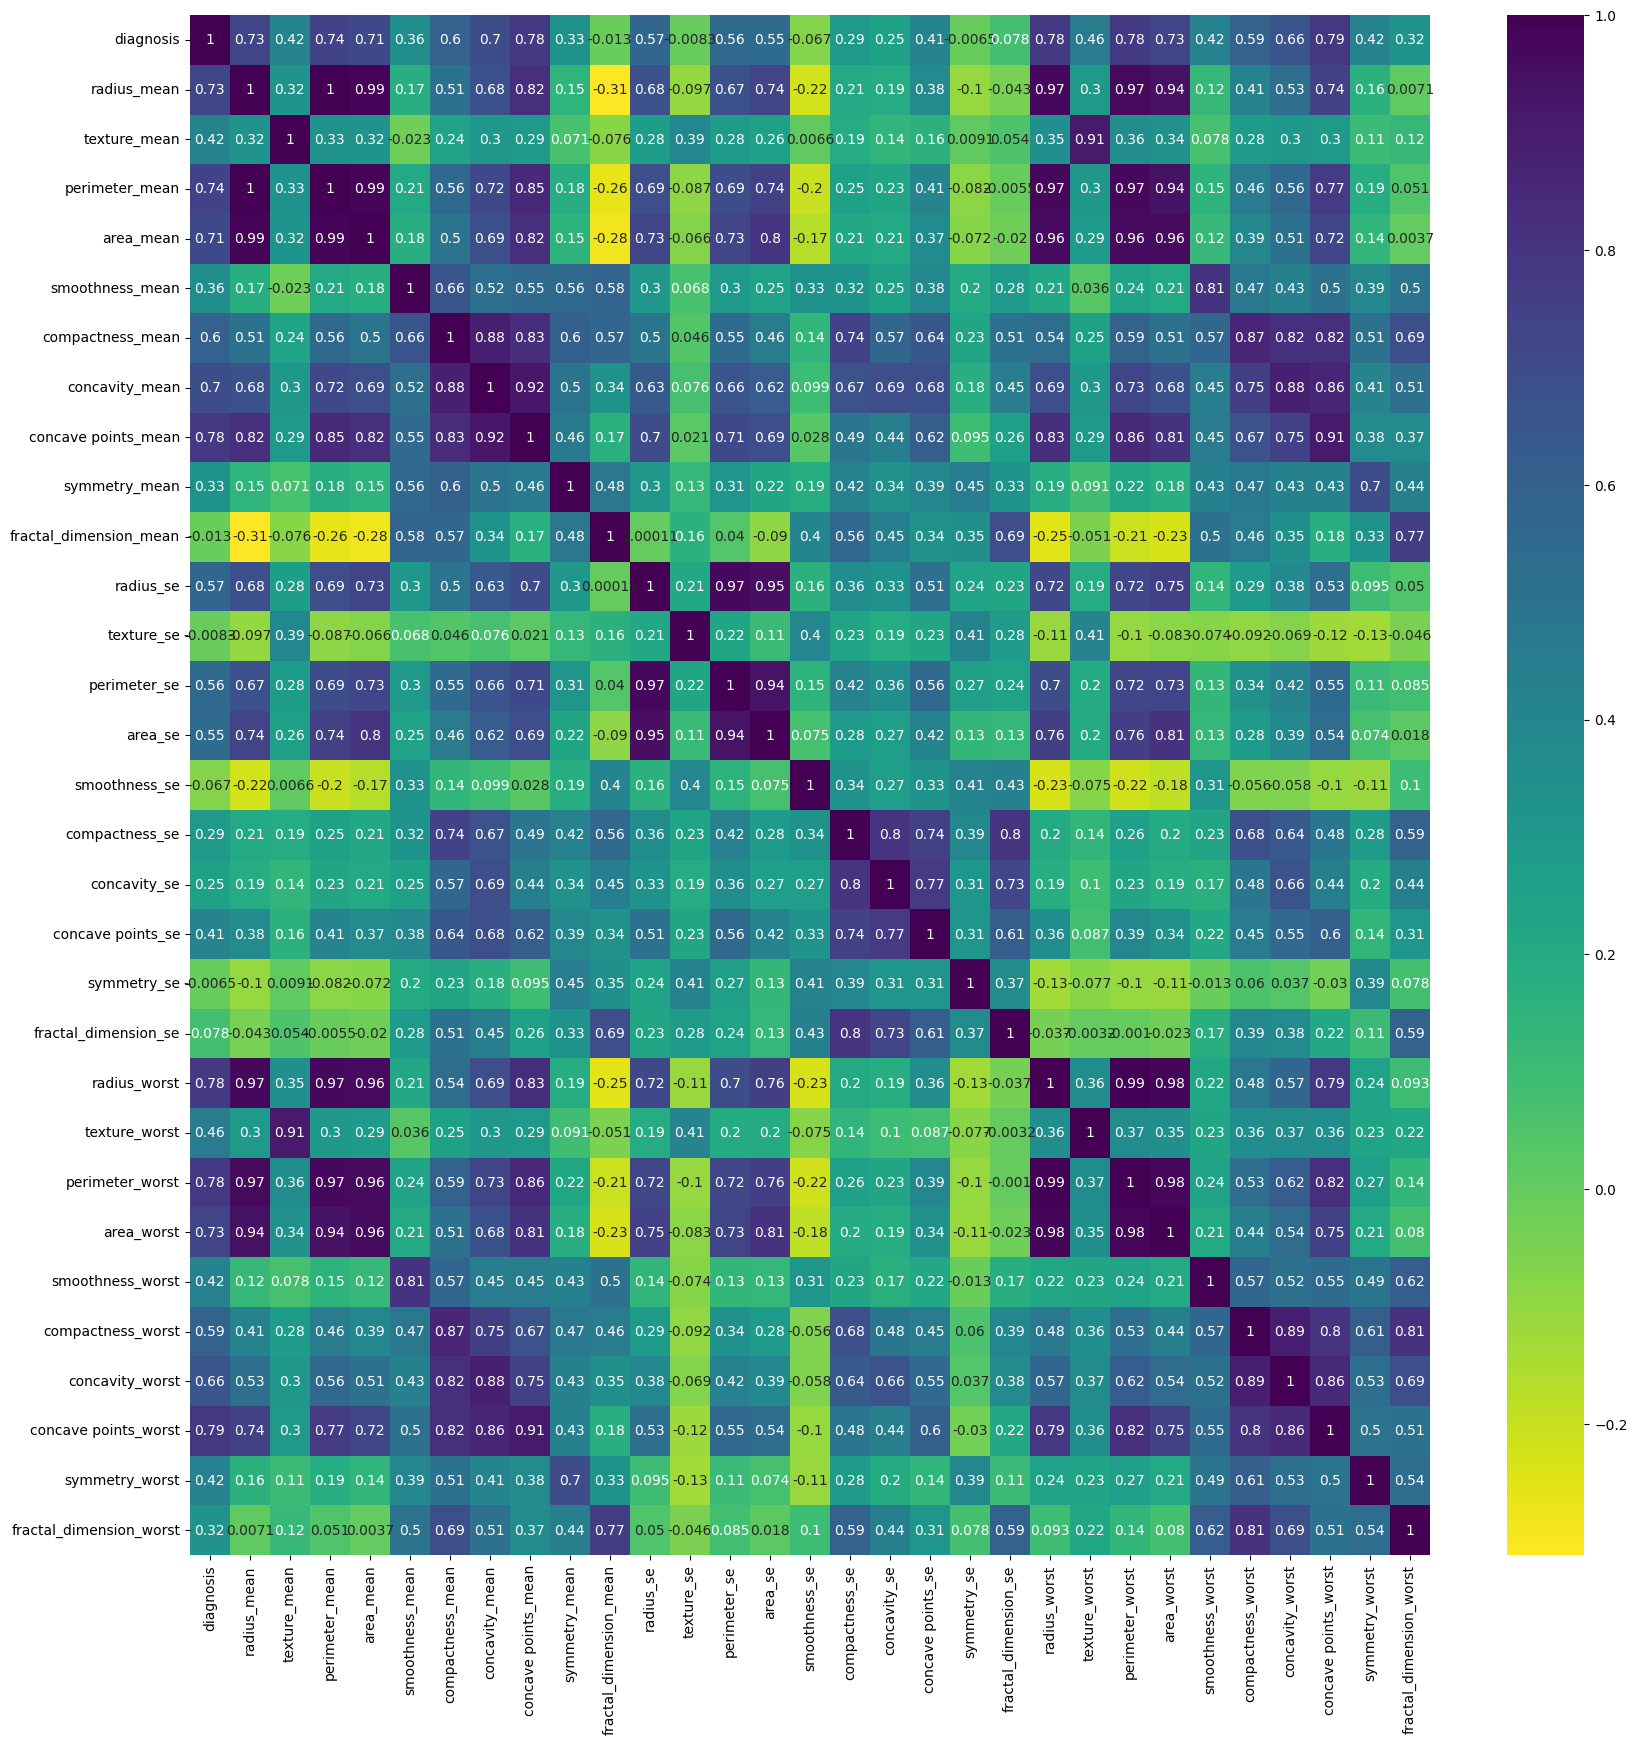

In [8]:
df['diagnosis'] = (df['diagnosis'] == 'M').astype(int) #encode the label into 1/0
corr = df.corr()
plt.figure(figsize=(20,20))
sns.heatmap(corr, cmap='viridis_r',annot=True)
plt.show() 

From this plot we conclude that:
- Some features aren't correlated with the target maybe we should remove them

### Feature Selection

In [9]:
# Get the absolute value of the correlation
cor_target = abs(corr['diagnosis'])

# Select highly correlated features (threshold = 0.99)
relevant_features = cor_target[cor_target > 0.25]

# Collect the names of the features
names = [index for index, vlaue in relevant_features.items()]

# Drop the target variable from the results
names.remove('diagnosis')

# Display the results
pprint.pprint(names)

['radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'radius_se',
 'perimeter_se',
 'area_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst']


##### Assigning training data and training labels

In [10]:
X = df[names].values
y = df['diagnosis'].values.reshape(-1, 1)

In [11]:
def scale(X):
    """
    Standardizes the data in the array X.

    Parameters:
        X (numpy.ndarray): Features array of shape (n_samples, n_features)

    Returns:
        numpy.ndarray: The standardized features array.
    """
    mean = np.mean(X, axis = 0)
    std = np.std(X, axis = 0)

    # Standardize the data
    X = (X - mean) / std
    return X

In [12]:
X = scale(X)

### Model Implementation

#### How the algorithm works
- We'll start with all examples at the root node:
- We'll calculate information gain for splitting on all possible features and pick the one with the highest value.
- Then we'll split the data according to the selected feature
- We'll repeat this process until stopping cirteria is met

#### Key Points:

**Entropy**

Entroy function is a way to measure impurity.

Entropy is represented by this function
$$\text{H} = - \sum p_{i} \log _2{p_i}$$
Where $(p_1)$ is the fraction of examples that are a certain class

**Information Gain**

Information gain is the **reduction** in entropy when he make a split

Recall that our goal is to choose the split that gives the highest information gain, information gain equation = 
$$H(p_1^{\text{node}}) - (w^{\text{left}}H(p_1^{\text{left}}) + w^{\text{right}}H(p_1^{\text{right}}))$$
where<br>
- $H(p_1^{\text{node}})$ is entropy at the node
- $H(p_1^{\text{left}})$ and $H(p_{1}^{\text{right}})$ are the entropies at the left and the right branches resulting from the split
- $w^{\text{left}}$ and $w^{\text{right}}$ are the proportion of examples at the left and right branch respectively.

### Implementation

Node Class

In [13]:
class Node():
    """
    A class representing a node in a decision tree.
    """

    def __init__(self, feature = None, threshold = None, left= None, right = None, gain = None, value =None):
        """
            Initializes a new instance of the Node class.

        Args:
            feature: The feature used for splitting at this node. Defaults to None.
            threshold: The threshold used for splitting at this node. Defaults to None.
            left: The left child node. Defaults to None.
            right: The right child node. Defaults to None.
            gain: The gain of the split. Defaults to None.
            value: If this node is a leaf node, this attribute represents the predicted value
                for the target variable. Defaults to None.
        """
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.gain = gain
        self.value = value


In [14]:
class DecisionTree:
    """
        A decision tree classifier for binary classification problems.
    """

    def __init__(self, min_samples = 2, max_depth = 2):
        """
        Parameters:
            min_samples (int): Minimum number of samples required to split an internal node.
            max_depth (int): Maximum depth of the decision tree.
        """
        self.min_samples = min_samples
        self.max_depth = max_depth
    
    def split_data(self, dataset, feature, threshold):
        """
        Splits the given dataset into two datasets based on the given feature and threshold.

        Parameters:
            dataset (ndarray): Input dataset.
            feature (int): Index of the feature to be split on.
            threshold (float): Threshold value to split the feature on.
        
        Returns:
            left_dataset (ndarray): subset of dataset with values less than or equal to the threshold.
            right_dataset (ndarray): subset of dataset with values greater than the threshold.
        """
        
        # Create empty arrays to store the left and right datasets.
        left_datasets = []
        right_datasets = []

        # Loop over 
        for row in dataset:
            if row[feature] <= threshold:
                left_datasets.append(row)
            else:
                right_datasets.append(row)
        
        # Convert the left and right datasets to numpy arrays and return
        left_datasets = np.array(left_datasets)
        right_datasets = np.array(right_datasets)
        return left_datasets, right_datasets

    def entropy(self, y):
        """
        Computes the entropy of the given label values.

        Parameters:
            y (ndarray): Input label values.

        Returns:
            entropy (float): Entropy of the given label values.
        """
        entropy = 0

        # Find the unique label values in y and loop over each value.
        labels = np.unique(y) # <-- a numpy array of all unique labels
        for label in labels:
            label_examples = y[y== label]

            # Calulate the ratio of current label
            pl = len(label_examples) / len(y)

            # Calculate the entropy using the current label and ratio
            entropy += -pl * np.log2(pl)
        
        return entropy

    def information_gain(self, parent, left, right):
        """
        Parameters:
            parent (ndarray): Input parent dataset
            left (ndarray): Subset of the parent dataset after split on a feature.
            right (ndarray): Subset of the parent dataset after split on a feature.

        Returns:
            information_gain (float): Information gain of the split.
        """
        information_gain = 0

        parent_entropy = self.entropy(parent)
        weight_left = len(left) / len(parent)
        weight_right = len(right) / len(parent)

        entropy_left, entropy_right = self.entropy(left), self.entropy(right)

        # Calculate weighted entropy
        weighted_entropy = weight_left * entropy_left + weight_right * entropy_right

        information_gain = parent_entropy - weighted_entropy

        return information_gain

    def best_split(self, dataset, num_samples, num_features):
        """
        Finds the best split for the given dataset.

        Args:
        dataset (ndarray): The dataset to split.
        num_samples (int): The number of samples in the datset.
        num_features (int): The number of features in the dataset.

        Returns:
        dict: A dictionary with the best split feature index, threshold, gain, left and right datasets.
        """
        # dictionary to store the best split values
        best_split = {'gain': -1, 'feature': None, 'threshold': None, 'left_dataset': None, 'right_dataset': None}
        
        for feature_index in range(num_features):
            feature_values = dataset[:, feature_index]
            thresholds = np.unique(feature_values)

            for threshold in thresholds:
                left_dataset, right_dataset = self.split_data(dataset, feature_index, threshold)
                if len(left_dataset) and len(right_dataset):
                    y, left_y, right_y = dataset[:, -1], left_dataset[:, -1], right_dataset[:, -1]

                    # compute thte information gain based on the y values
                    information_gain = self.information_gain(y, left_y, right_y)

                    # update the best split if conditons are met
                    if information_gain > best_split["gain"]:
                        best_split["feature"] = feature_index
                        best_split["threshold"] = threshold
                        best_split["left_dataset"] = left_dataset
                        best_split["right_dataset"] = right_dataset
                        best_split["gain"] = information_gain
        return best_split

    def calculate_leaf_value(self, y):
        """
            Calculate the most occuring value in the given list of y values.
            Args:
                y (list): The list of y values.
            Returns:
                The most occuring value in the list.
        """
        y = list(y)
        most_occuring_value = max(y, key=y.count)
        return most_occuring_value

    def build_tree(self, dataset, current_depth = 0):
        """
            Recursively builds a decision tree from the given dataset.

            Args: 
                dataset: The dataset to build the tree from. 
                current_depth (int): The current depth of the tree.
            Returns:
                Node: The root node of the built decision tree. 
        """

        # Split the dataset into X, y values
        X, y = dataset[:, :-1], dataset[:, -1]
        n_samples, n_features = X.shape

        # keep splitting until stopping conditons are met   
        if n_samples >= self.min_samples and current_depth <= self.max_depth:
            best_split = self.best_split(dataset, n_samples, n_features)

            # Check if gain isn't zero
            if best_split["gain"]:
                # continue splitting the left and right child. INcrement current depth.
                left_node = self.build_tree(best_split["left_dataset"], current_depth + 1)
                right_node = self.build_tree(best_split["right_dataset"], current_depth + 1)

                return Node(best_split["feature"], best_split["threshold"], left_node, right_node, best_split["gain"])
        
        # compute leaf node value
        leaf_value = self.calculate_leaf_value(y)
        return Node(value = leaf_value)

    def fit(self, X, y):
        dataset = np.concatenate((X, y), axis = 1)
        self.root = self.build_tree(dataset)


    def predict(self, X):
        """
            Build and fits the decision tree to the given X and y values.

            Args:
            X (ndarray): The feature matrix.
            y (ndarray): The target values.
        """
        predictions = []
        for x in X:
            prediction = self.make_predictions(x, self.root)
            predictions.append(prediction)
        np.array(predictions)
        return predictions
    

    def make_predictions(self, x, node):
        """
        Traverses the decision tree to predict the target value for the given feature vector.

        Args:
            x (ndarray): The feature vector to predict the target value for.
            node (Node): The current node being evaulated. 
        
        Returns:
            The predicted target value for the given feature vector.
        """
        # if the node has value i.e it's a leaf node extract it's value
        if node.value != None:
            return node.value
        else:
            feature = x[node.feature]
            if feature <= node.threshold:
                return self.make_predictions(x, node.left)
            else:
                return self.make_predictions(x, node.right)

### Evaluation

In [15]:
def train_test_split(X, y, random_state= 41, test_size = 0.2):
    """
    Parameters: 
        X (numpy.ndarray): Features array of shape (n_samples, n_features)
        y (numpy.ndarray): Target array of shape (n_samples, )
        randome_state (int): Seed for the random number generator
        test_size (float): Proportion of samples to include in the test set. Default is 0.2.

    Returns:
        Tuple[numpy.ndarray]: A tuple containing X_train, X_test, y_train, y_test     
    """

    # Get number of samples
    n_samples = X.shape[0]

    # Set the seed for the random number generator
    np.random.seed(random_state)

    # shuffle the indices
    shuffled_indices = np.random.permutation(np.arange(n_samples))

    # Determien the size of the test set
    test_size = int(n_samples * test_size)
    test_indices = shuffled_indices[: test_size]
    train_indices = shuffled_indices[test_size:]

    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    return X_train, X_test, y_train, y_test


In [16]:
def accuracy(y_true, y_pred):
    y_true = y_true.flatten()
    total_samples = len(y_true)
    correct_predictions = np.sum(y_true == y_pred)
    return correct_predictions/total_samples

In [17]:
# Below is an example to help you understand how np.concatenate() work.

ex1 = np.array([[1,2, 3], [4, 5, 6], [7, 8, 9]])
ex2 = np.array([6, 3, 5])
ex2 = np.expand_dims(ex2, axis = 1)
print(ex2)
res = np.concatenate((ex1, ex2), axis = 1)
print(res)

[[6]
 [3]
 [5]]
[[1 2 3 6]
 [4 5 6 3]
 [7 8 9 5]]


#### Balanced Accuracy
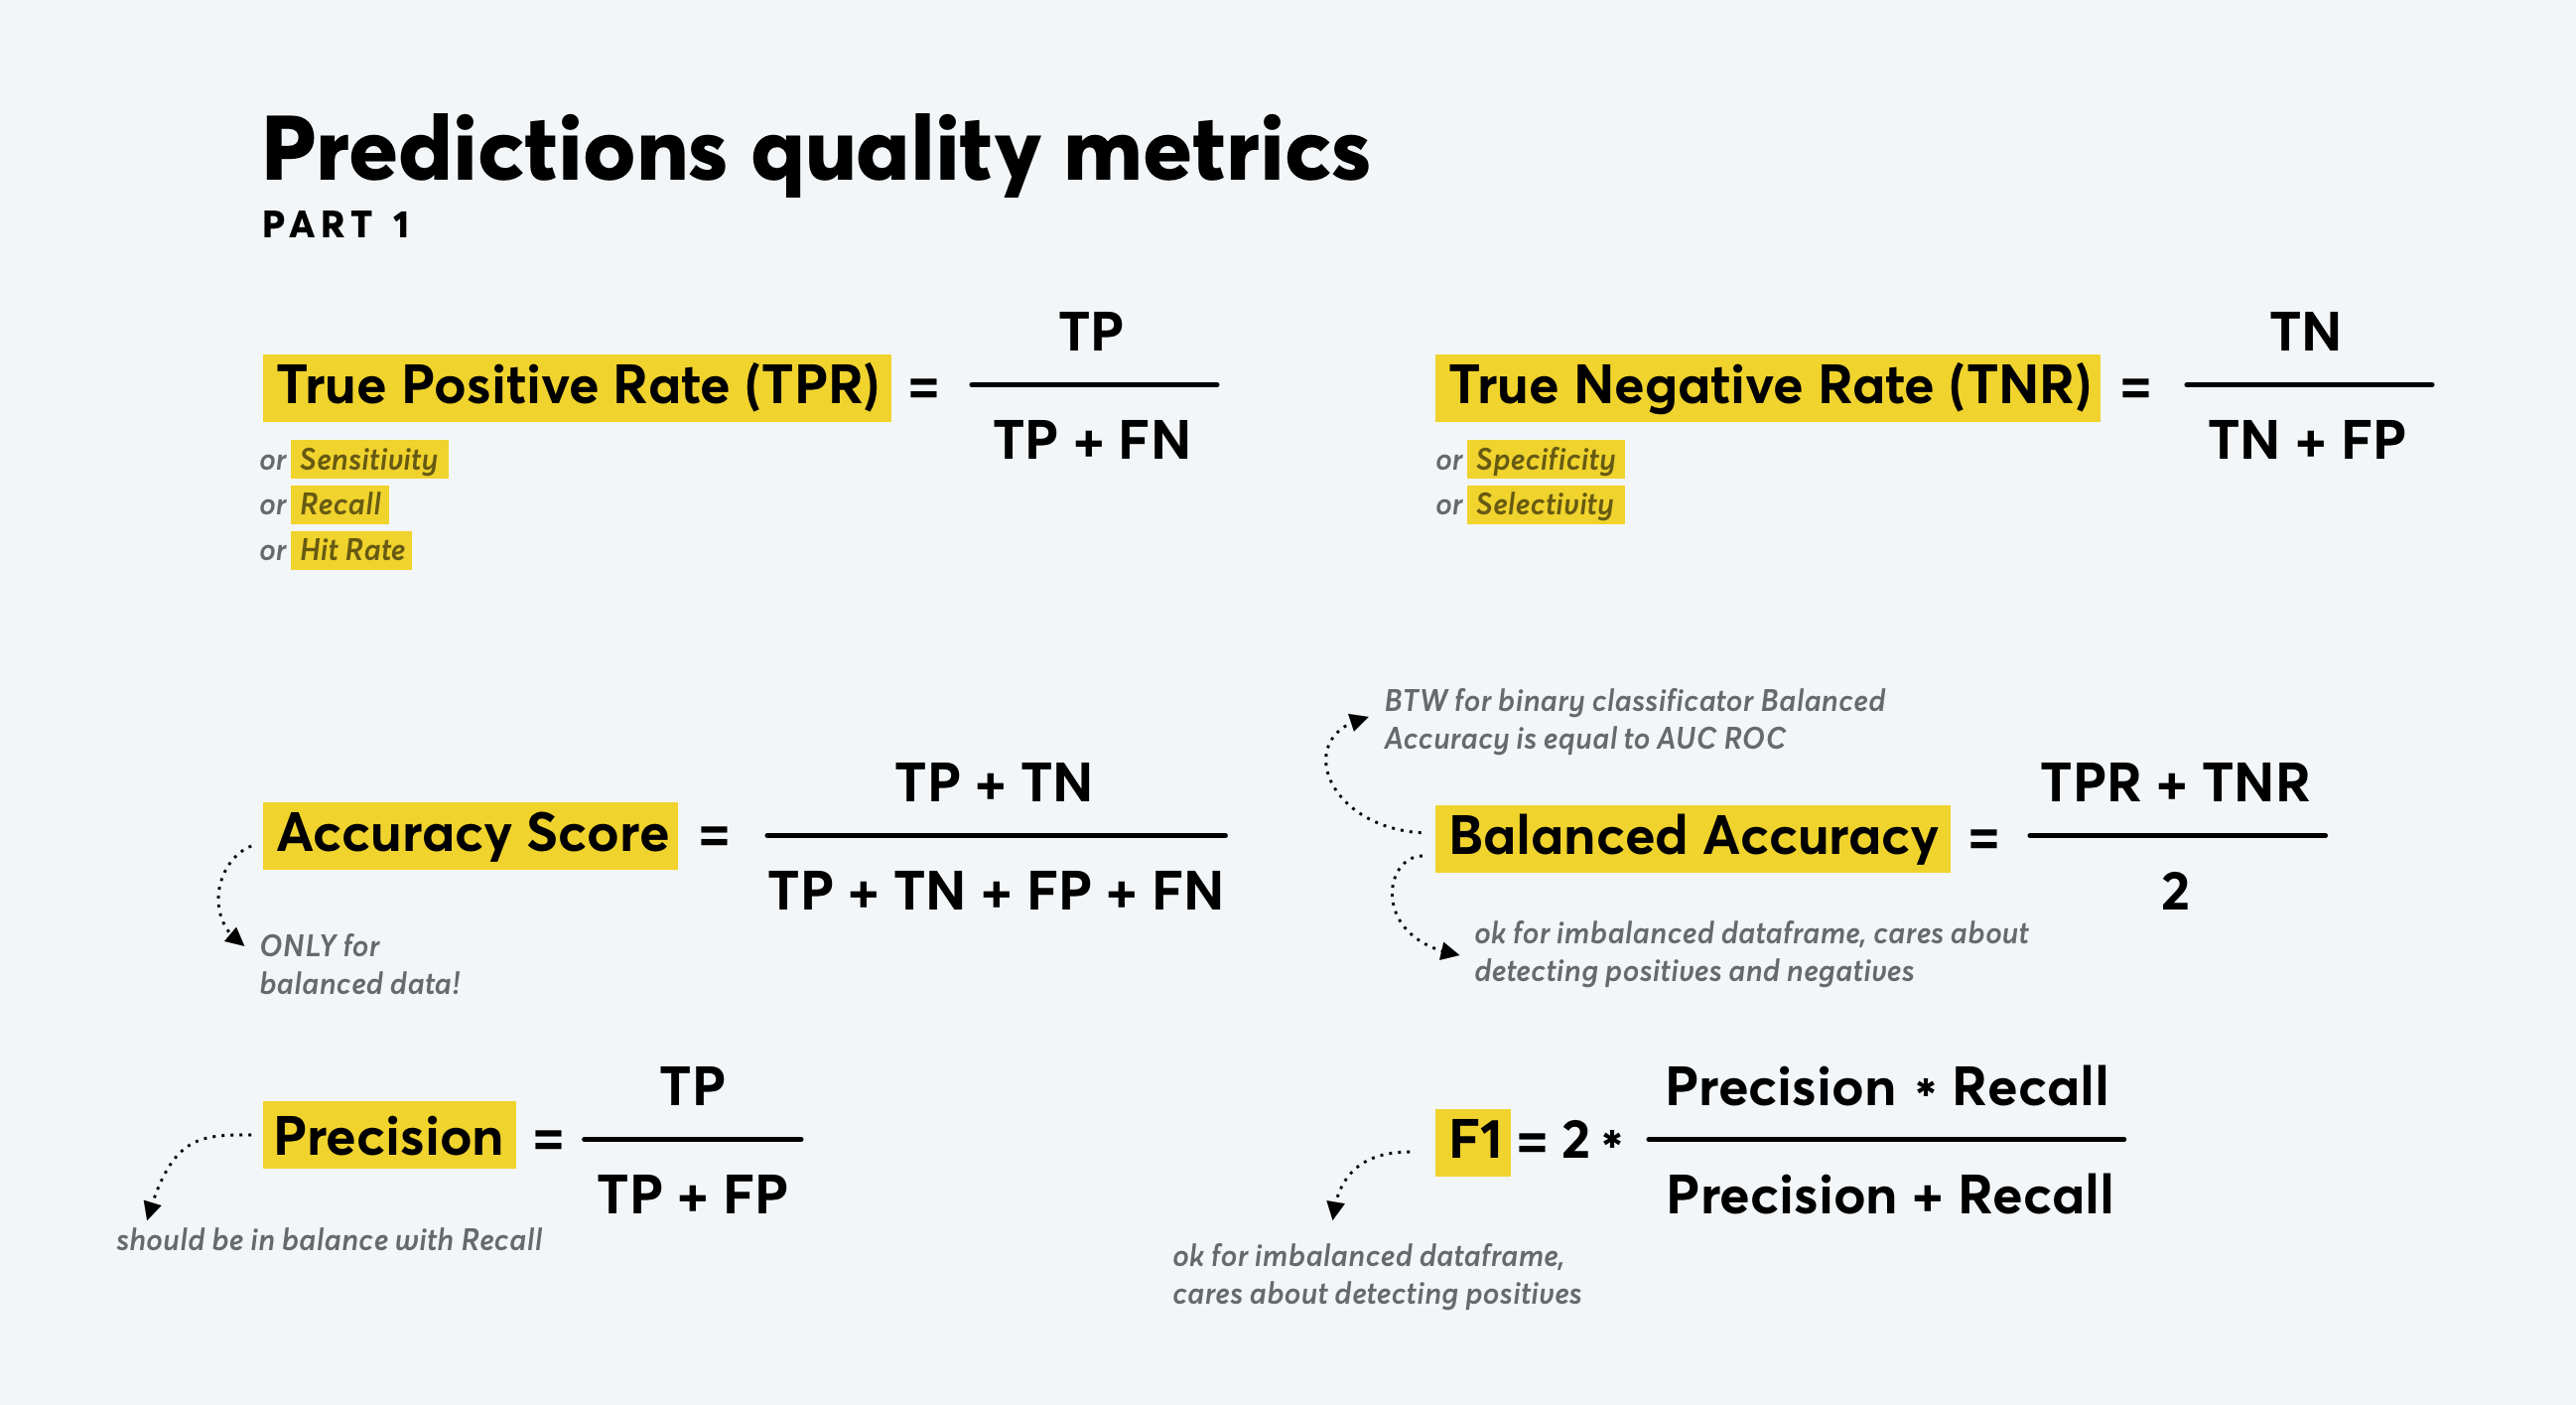

In [18]:
a = np.array([[[1, 2, 3]],
              [[4, 5, 6]]])

b = a.flatten()
print(b)

[1 2 3 4 5 6]


In [19]:
def balanced_accuracy(y_true, y_pred):
    """
        Calculate the balanced accuracy for multi-clasa classification problem.

        Parameters:
            y_true (numpy array): A numpy array of true labels for each data point.
            y_pred (numpy array): A numpy array of predicted labels for each data point.
        
        Returns:
            balanced_acc: The balanced accuracy of the model
    """
    y_pred = np.array(y_pred)
    y_true = y_true.flatten()

    # Get the number of classes
    n_classes = len(np.unique(y_true))

    # Initialize an array to store the sensitivity and specificity for each class
    sen = []
    spec = []

    for i in range(n_classes):  # The reason that this still works with range(n_classes) is because we are labelling class labels from 0 to 4
        
        # Create a mask for the true and predicted values for class i
        mask_true = y_true == i   # --> a numpy array of trues and falses
        mask_pred = y_pred == i   # --> a numpy array of trues and falses

        # Calculate the true positives, true negatives, false positives, false negatives
        TP = np.sum(mask_true & mask_pred)
        TN = np.sum((mask_true != True) & (mask_pred != True))
        FP = np.sum((mask_true != True) * mask_pred)
        FN = np.sum(mask_true  & (mask_pred != True))

        # Calculate sensitivity and specificity
        sensitivity = TP / (TP + FN)
        specificity = TN / (TN + FP)

        sen.append(sensitivity)
        spec.append(specificity)

    # Calculate the balanced accuracy as the average of the sensitivity and specificity for each class
    average_sen = np.mean(sen)
    average_spec = np.mean(spec)
    balanced_acc = (average_sen + average_spec)/ n_classes

    return balanced_acc


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=41, test_size=0.2)

In [21]:
model = DecisionTree(2, 2)

model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(predictions)

# Calculate evaluating metrics
print(f"Model's accuracy: {accuracy(y_test, predictions)}")
print(f"Model's Balanced Accuracy: {balanced_accuracy(y_test, predictions)}")

[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(0.

### SKLearn Implementation

In [61]:
from sklearn.tree import DecisionTreeClassifier

In [62]:
decision_tree_classifier = DecisionTreeClassifier()

decision_tree_classifier.fit(X_train, y_train)

predictions = decision_tree_classifier.predict(X_test)

# Calculate evaluating metrics
print(f" Model's Accuracy: {accuracy(y_test, predictions)}")
print(f"Model's Balanced Accuracy: {balanced_accuracy(y_test, predictions)}")

 Model's Accuracy: 0.9469026548672567
Model's Balanced Accuracy: 0.9476027397260274
